In [1]:
from pathlib import Path
import shutil
import random
import re
import xml.etree.ElementTree as ET
from collections import defaultdict

# =========================
# Paths
# =========================

PROJECT_ROOT = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection"
)

OLD_DATASET = PROJECT_ROOT / "food30_yolo"
NEW_DATASET = PROJECT_ROOT / "food41_yolo"

ECUST_ROOT = PROJECT_ROOT / "ECUSTFD-resized--master"
ECUST_IMAGES = ECUST_ROOT / "JPEGImages"
ECUST_ANNOTATIONS = ECUST_ROOT / "Annotations"

# =========================
# Existing 30 classes
# =========================

OLD_CLASSES = {
    0: "rice",
    1: "sushi",
    2: "fried rice",
    3: "toast",
    4: "croissant",
    5: "hamburger",
    6: "pizza",
    7: "sandwiches",
    8: "ramen noodle",
    9: "spaghetti",
    10: "gratin",
    11: "miso soup",
    12: "sausage",
    13: "omelet",
    14: "grilled salmon",
    15: "fried chicken",
    16: "steak",
    17: "egg sunny-side up",
    18: "roast chicken",
    19: "potato salad",
    20: "green salad",
    21: "rice ball",
    22: "hot dog",
    23: "french fries",
    24: "pancake",
    25: "mushroom risotto",
    26: "chicken nugget",
    27: "scrambled egg",
    28: "lasagna",
    29: "brownie",
}

# =========================
# New ECUSTFD classes
# =========================

ECUST_CLASS_MAP = {
    "apple": 30,
    "banana": 31,
    "tomato": 32,
    "lemon": 33,
    "litchi": 34,
    "mango": 35,
    "orange": 36,
    "peach": 37,
    "pear": 38,
    "plum": 39,
    "qiwi": 40,   # renamed to kiwi in final dataset
}

FINAL_CLASS_NAMES = {
    **OLD_CLASSES,
    30: "apple",
    31: "banana",
    32: "tomato",
    33: "lemon",
    34: "litchi",
    35: "mango",
    36: "orange",
    37: "peach",
    38: "pear",
    39: "plum",
    40: "kiwi",
}

# =========================
# Copy old dataset
# =========================

if NEW_DATASET.exists():
    shutil.rmtree(NEW_DATASET)

shutil.copytree(OLD_DATASET, NEW_DATASET)

print("Copied food30_yolo -> food41_yolo")

# =========================
# Create grouped samples
# =========================

samples_by_class = defaultdict(lambda: defaultdict(list))

for class_name in ECUST_CLASS_MAP:

    for image_path in ECUST_IMAGES.glob(f"{class_name}*.JPG"):

        match = re.match(
            rf"({re.escape(class_name)}\d+)[ST]\(\d+\)",
            image_path.stem
        )

        if match:
            sample_id = match.group(1)
            samples_by_class[class_name][sample_id].append(image_path)

# =========================
# Group-aware split
# =========================

random.seed(42)

split_assignments = {}

for class_name, samples in samples_by_class.items():

    sample_ids = list(samples.keys())
    random.shuffle(sample_ids)

    n = len(sample_ids)

    # target ratio ~= 64 / 16 / 20
    n_train = max(1, round(n * 0.64))
    n_val = max(1, round(n * 0.16))

    # ensure at least 1 test sample
    if n_train + n_val >= n:
        n_train = max(1, n - 2)
        n_val = 1

    n_test = n - n_train - n_val

    train_ids = sample_ids[:n_train]
    val_ids = sample_ids[n_train:n_train + n_val]
    test_ids = sample_ids[n_train + n_val:]

    for sid in train_ids:
        split_assignments[sid] = "train"

    for sid in val_ids:
        split_assignments[sid] = "val"

    for sid in test_ids:
        split_assignments[sid] = "test"

# =========================
# VOC bbox -> YOLO
# =========================

def convert_bbox_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h):

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h

    return x_center, y_center, width, height

# =========================
# Convert ECUSTFD
# =========================

added_counts = {
    "train": 0,
    "val": 0,
    "test": 0
}

class_image_counts = defaultdict(lambda: defaultdict(int))

for class_name, samples in samples_by_class.items():

    for sample_id, image_paths in samples.items():

        split = split_assignments[sample_id]

        for image_path in image_paths:

            xml_path = ECUST_ANNOTATIONS / f"{image_path.stem}.xml"

            if not xml_path.exists():
                print("Missing annotation:", xml_path.name)
                continue

            tree = ET.parse(xml_path)
            root = tree.getroot()

            size = root.find("size")
            img_w = int(size.find("width").text)
            img_h = int(size.find("height").text)

            yolo_lines = []

            for obj in root.findall("object"):

                obj_name = obj.find("name").text.strip()

                # ignore calibration coin
                if obj_name == "coin":
                    continue

                # only selected ECUST classes
                if obj_name not in ECUST_CLASS_MAP:
                    continue

                class_id = ECUST_CLASS_MAP[obj_name]

                bbox = obj.find("bndbox")

                xmin = float(bbox.find("xmin").text)
                ymin = float(bbox.find("ymin").text)
                xmax = float(bbox.find("xmax").text)
                ymax = float(bbox.find("ymax").text)

                # clip to image bounds
                xmin = max(0, min(xmin, img_w))
                xmax = max(0, min(xmax, img_w))
                ymin = max(0, min(ymin, img_h))
                ymax = max(0, min(ymax, img_h))

                if xmax <= xmin or ymax <= ymin:
                    continue

                x_c, y_c, w, h = convert_bbox_to_yolo(
                    xmin, ymin, xmax, ymax,
                    img_w, img_h
                )

                yolo_lines.append(
                    f"{class_id} "
                    f"{x_c:.6f} "
                    f"{y_c:.6f} "
                    f"{w:.6f} "
                    f"{h:.6f}"
                )

            if not yolo_lines:
                continue

            # unique filename prefix to avoid collision
            output_stem = f"ecust_{image_path.stem}"

            out_img = NEW_DATASET / "images" / split / f"{output_stem}.jpg"
            out_lbl = NEW_DATASET / "labels" / split / f"{output_stem}.txt"

            shutil.copy2(image_path, out_img)

            with open(out_lbl, "w", encoding="utf-8") as f:
                f.write("\n".join(yolo_lines))

            added_counts[split] += 1
            class_image_counts[class_name][split] += 1

# =========================
# Create dataset.yaml
# =========================

yaml_lines = [
    "path: /content/food41_yolo",
    "",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "",
    "names:"
]

for class_id in sorted(FINAL_CLASS_NAMES):
    yaml_lines.append(
        f"  {class_id}: {FINAL_CLASS_NAMES[class_id]}"
    )

yaml_path = NEW_DATASET / "dataset.yaml"

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write("\n".join(yaml_lines))

# =========================
# Create class mapping
# =========================

mapping_path = NEW_DATASET / "class_mapping.txt"

with open(mapping_path, "w", encoding="utf-8") as f:
    for class_id in sorted(FINAL_CLASS_NAMES):
        f.write(
            f"{class_id}: {FINAL_CLASS_NAMES[class_id]}\n"
        )

# =========================
# Final report
# =========================

print("\nDone.")

print("\nAdded ECUSTFD images:")
for split in ["train", "val", "test"]:
    print(f"{split}: {added_counts[split]}")

print("\nECUSTFD class distribution:")

for class_name in ECUST_CLASS_MAP:

    display_name = "kiwi" if class_name == "qiwi" else class_name

    print(
        f"{display_name:<10} "
        f"train={class_image_counts[class_name]['train']:<4} "
        f"val={class_image_counts[class_name]['val']:<4} "
        f"test={class_image_counts[class_name]['test']:<4}"
    )

print("\nFinal dataset:")
for split in ["train", "val", "test"]:

    images = list(
        (NEW_DATASET / "images" / split).glob("*")
    )

    labels = list(
        (NEW_DATASET / "labels" / split).glob("*.txt")
    )

    print(
        f"{split:<5} "
        f"images={len(images)} "
        f"labels={len(labels)}"
    )

print("\nDataset path:")
print(NEW_DATASET)

print("\nYAML path:")
print(yaml_path)

Copied food30_yolo -> food41_yolo

Done.

Added ECUSTFD images:
train: 1223
val: 304
test: 407

ECUSTFD class distribution:
apple      train=171  val=38   test=87  
banana     train=132  val=16   test=30  
tomato     train=122  val=30   test=20  
lemon      train=88   val=24   test=36  
litchi     train=46   val=16   test=16  
mango      train=130  val=42   test=48  
orange     train=192  val=26   test=36  
peach      train=70   val=16   test=40  
pear       train=120  val=32   test=14  
plum       train=82   val=46   test=48  
kiwi       train=70   val=18   test=32  

Final dataset:
train images=4811 labels=4811
val   images=1185 labels=1185
test  images=1507 labels=1507

Dataset path:
/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food41_yolo

YAML path:
/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food41_yolo/dataset.yaml


In [2]:
from pathlib import Path
from collections import Counter

DATASET = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food41_yolo"
)

errors = []
class_counts = Counter()

for split in ["train", "val", "test"]:

    image_dir = DATASET / "images" / split
    label_dir = DATASET / "labels" / split

    images = {
        p.stem for p in image_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    }

    labels = {
        p.stem for p in label_dir.glob("*.txt")
    }

    print(f"\n--- {split.upper()} ---")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Images without labels:", len(images - labels))
    print("Labels without images:", len(labels - images))

    if images - labels:
        errors.append(
            f"{split}: images without labels"
        )

    if labels - images:
        errors.append(
            f"{split}: labels without images"
        )

    for label_path in label_dir.glob("*.txt"):

        with open(label_path, "r") as f:

            for line_num, line in enumerate(f, start=1):

                parts = line.strip().split()

                if len(parts) != 5:
                    errors.append(
                        f"{label_path.name}: invalid format"
                    )
                    continue

                try:
                    class_id = int(parts[0])
                    x, y, w, h = map(float, parts[1:])
                except ValueError:
                    errors.append(
                        f"{label_path.name}: invalid values"
                    )
                    continue

                if not 0 <= class_id <= 40:
                    errors.append(
                        f"{label_path.name}: invalid class {class_id}"
                    )

                if not (
                    0 <= x <= 1 and
                    0 <= y <= 1 and
                    0 < w <= 1 and
                    0 < h <= 1
                ):
                    errors.append(
                        f"{label_path.name}: invalid bbox"
                    )

                class_counts[class_id] += 1


print("\n======================")

if not errors:
    print("✓ ALL LABEL VALIDATIONS PASSED")
else:
    print("Errors:", len(errors))

    for error in errors[:20]:
        print(error)

print("\nTotal objects:", sum(class_counts.values()))


--- TRAIN ---
Images: 4811
Labels: 4811
Images without labels: 0
Labels without images: 0

--- VAL ---
Images: 1185
Labels: 1185
Images without labels: 0
Labels without images: 0

--- TEST ---
Images: 1507
Labels: 1507
Images without labels: 0
Labels without images: 0

✓ ALL LABEL VALIDATIONS PASSED

Total objects: 7661


In [3]:
import re
from collections import defaultdict

sample_splits = defaultdict(set)

for split in ["train", "val", "test"]:

    image_dir = DATASET / "images" / split

    for image_path in image_dir.glob("ecust_*"):

        name = image_path.stem

        match = re.match(
            r"ecust_([a-z_]+\d+)[ST]\(\d+\)",
            name
        )

        if match:
            sample_id = match.group(1)
            sample_splits[sample_id].add(split)


leakage = {
    sample_id: splits
    for sample_id, splits in sample_splits.items()
    if len(splits) > 1
}

print("ECUSTFD physical samples:", len(sample_splits))
print("Samples appearing in multiple splits:", len(leakage))

if leakage:
    print("\nLEAKAGE FOUND:")

    for sample_id, splits in leakage.items():
        print(sample_id, splits)

else:
    print("\n✓ NO ECUSTFD DATA LEAKAGE")

ECUSTFD physical samples: 95
Samples appearing in multiple splits: 0

✓ NO ECUSTFD DATA LEAKAGE


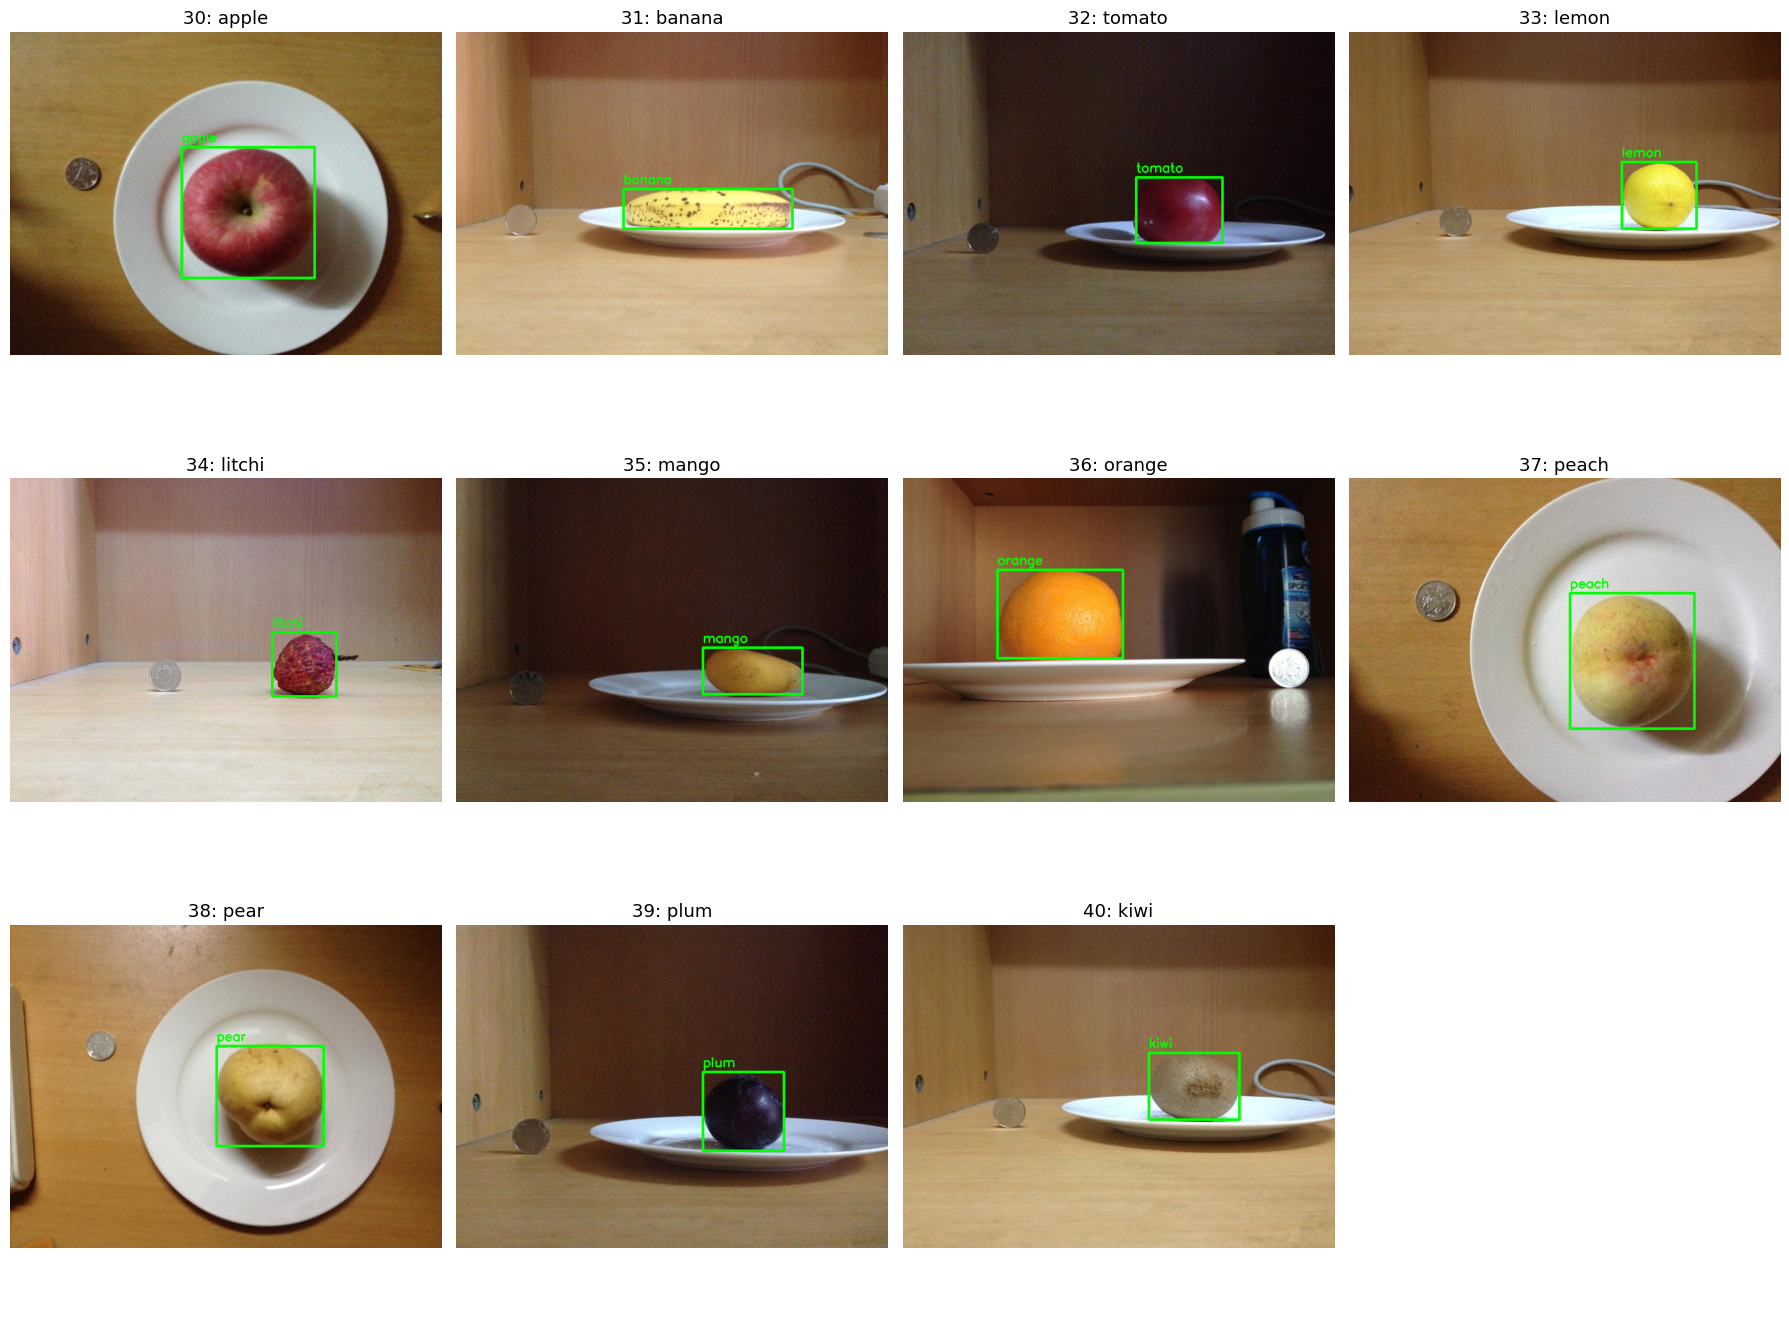

In [4]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

DATASET = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food41_yolo"
)

NEW_CLASSES = {
    30: "apple",
    31: "banana",
    32: "tomato",
    33: "lemon",
    34: "litchi",
    35: "mango",
    36: "orange",
    37: "peach",
    38: "pear",
    39: "plum",
    40: "kiwi"
}

image_dir = DATASET / "images" / "train"
label_dir = DATASET / "labels" / "train"

# Find images belonging to each new class
images_by_class = {class_id: [] for class_id in NEW_CLASSES}

for label_path in label_dir.glob("ecust_*.txt"):

    with open(label_path, "r") as f:
        class_ids = {
            int(line.split()[0])
            for line in f
            if line.strip()
        }

    for class_id in class_ids:
        if class_id in NEW_CLASSES:
            images_by_class[class_id].append(label_path.stem)


# Pick one random image per class
random.seed(42)

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()

for ax, (class_id, class_name) in zip(
    axes,
    NEW_CLASSES.items()
):

    candidates = images_by_class[class_id]

    if not candidates:
        ax.set_title(f"{class_name} - NOT FOUND")
        ax.axis("off")
        continue

    stem = random.choice(candidates)

    # Find corresponding image
    image_path = None

    for ext in [".jpg", ".JPG", ".jpeg", ".png"]:
        candidate = image_dir / f"{stem}{ext}"

        if candidate.exists():
            image_path = candidate
            break

    if image_path is None:
        ax.set_title(f"{class_name} - IMAGE ERROR")
        ax.axis("off")
        continue

    label_path = label_dir / f"{stem}.txt"

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    with open(label_path, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            cid = int(parts[0])
            x_center, y_center, bw, bh = map(
                float,
                parts[1:]
            )

            # YOLO normalized -> pixels
            x_center *= w
            y_center *= h
            bw *= w
            bh *= h

            x1 = int(x_center - bw / 2)
            y1 = int(y_center - bh / 2)
            x2 = int(x_center + bw / 2)
            y2 = int(y_center + bh / 2)

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                3
            )

            label = NEW_CLASSES.get(cid, str(cid))

            cv2.putText(
                image,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )

    ax.imshow(image)
    ax.set_title(
        f"{class_id}: {class_name}",
        fontsize=13
    )
    ax.axis("off")


# Hide unused 12th subplot
for ax in axes[len(NEW_CLASSES):]:
    ax.axis("off")

plt.tight_layout()
plt.show()